In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))
Path.cwd()

PosixPath('/home/avash/Documents/research/transformer-pt-analysis-main/src/Analysis')

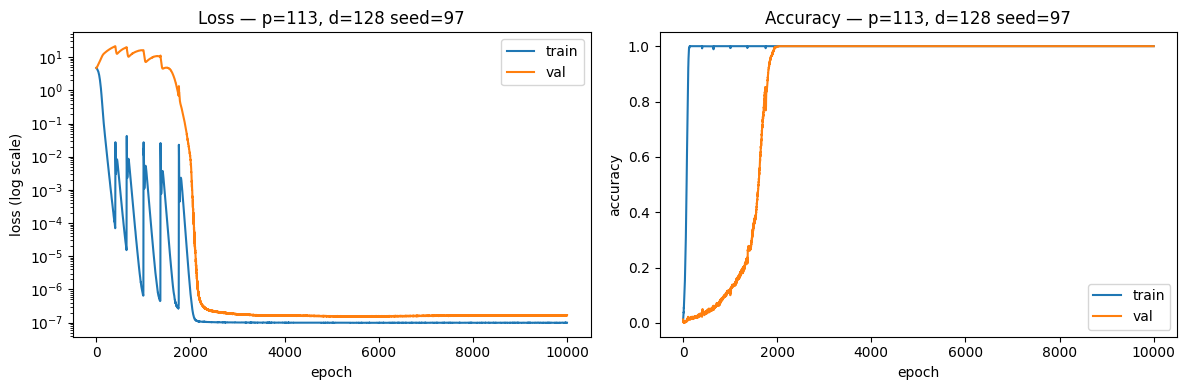

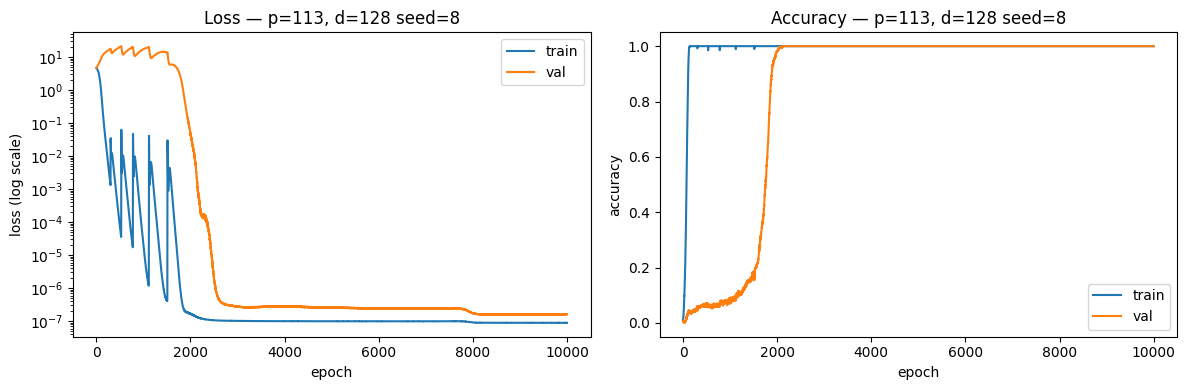

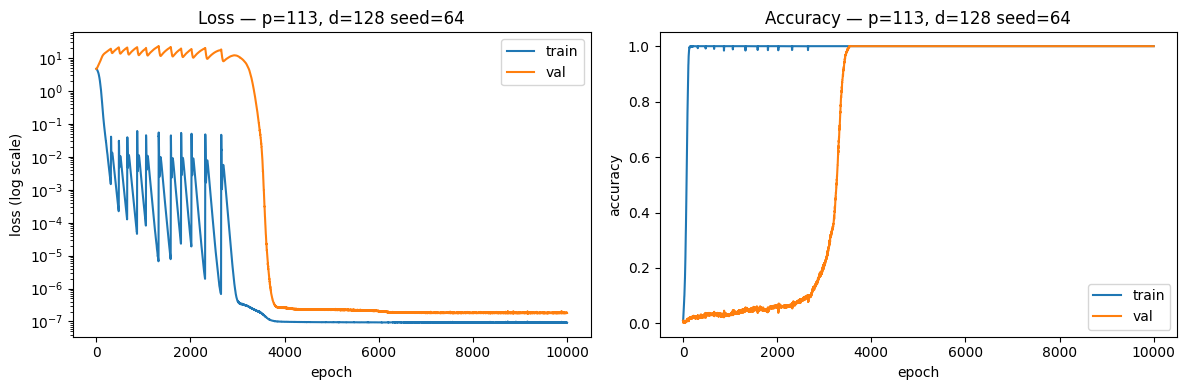

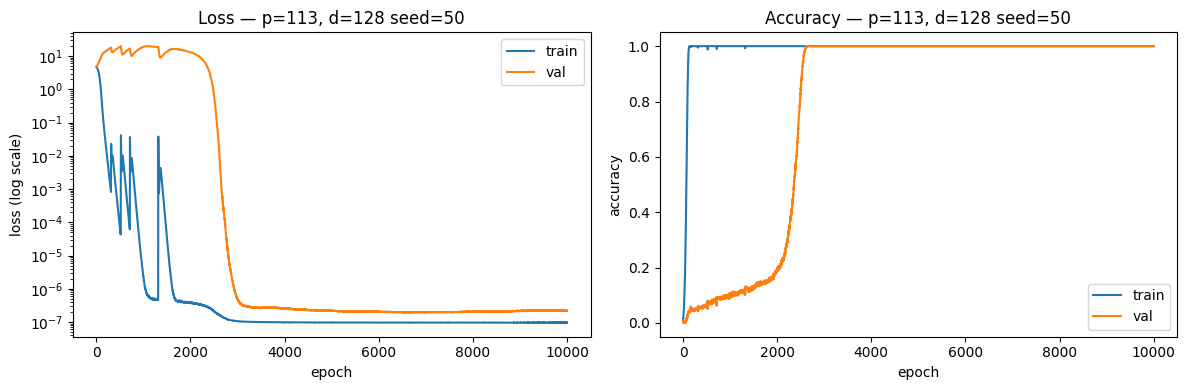

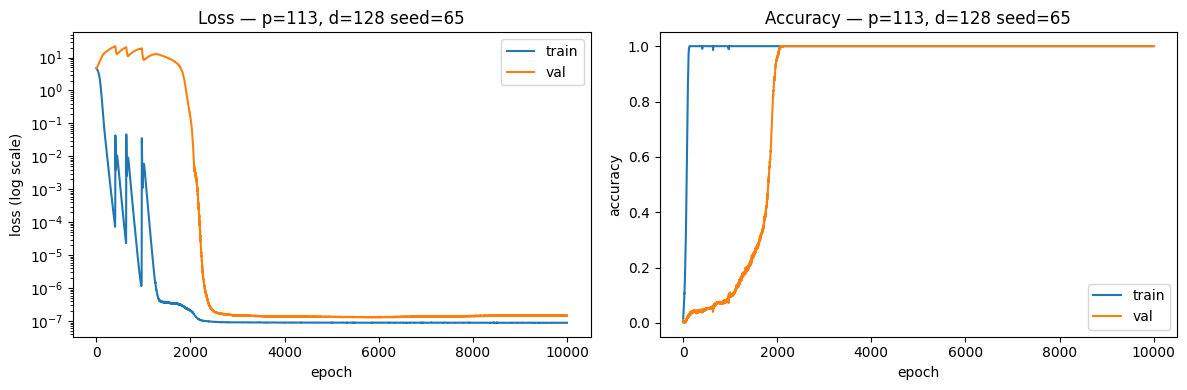

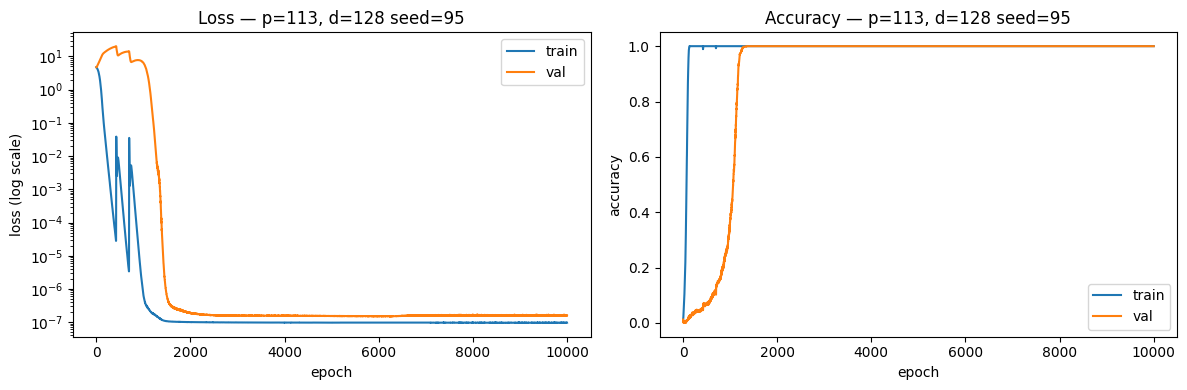

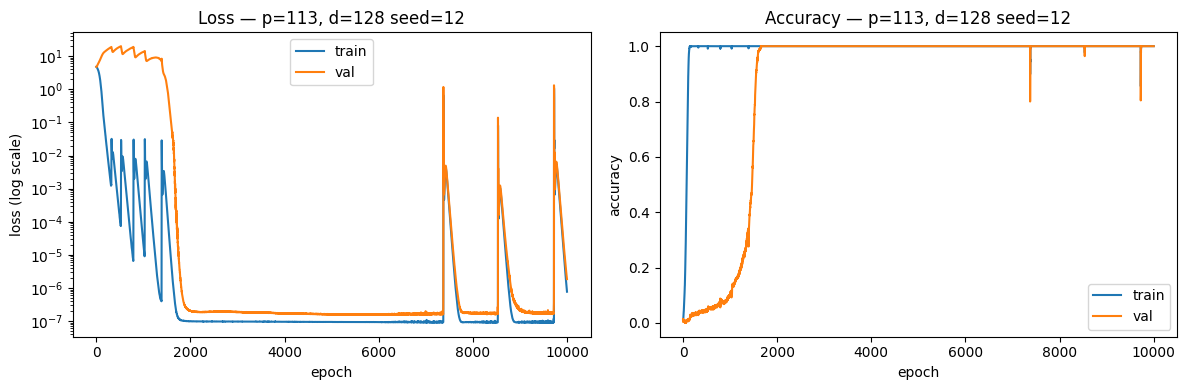

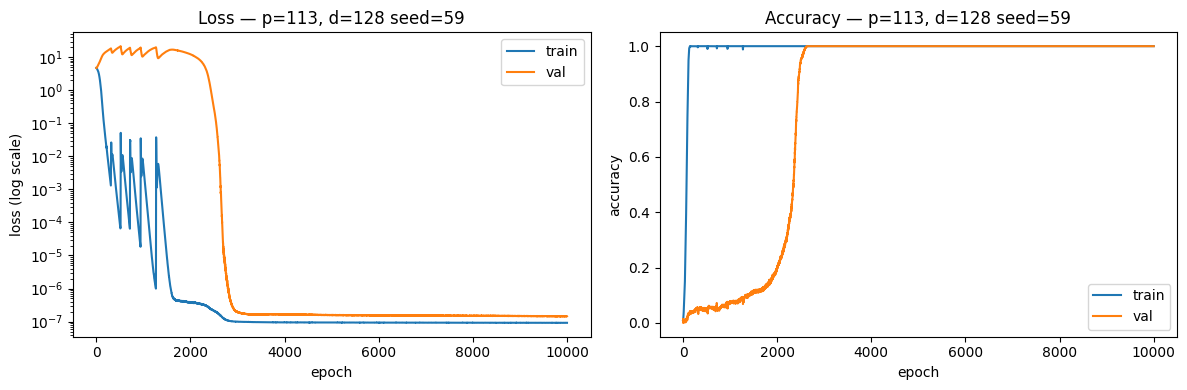

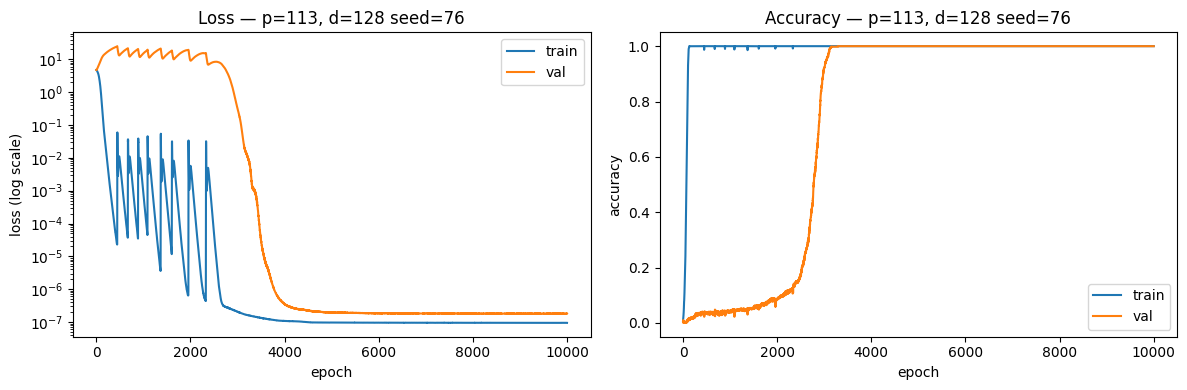

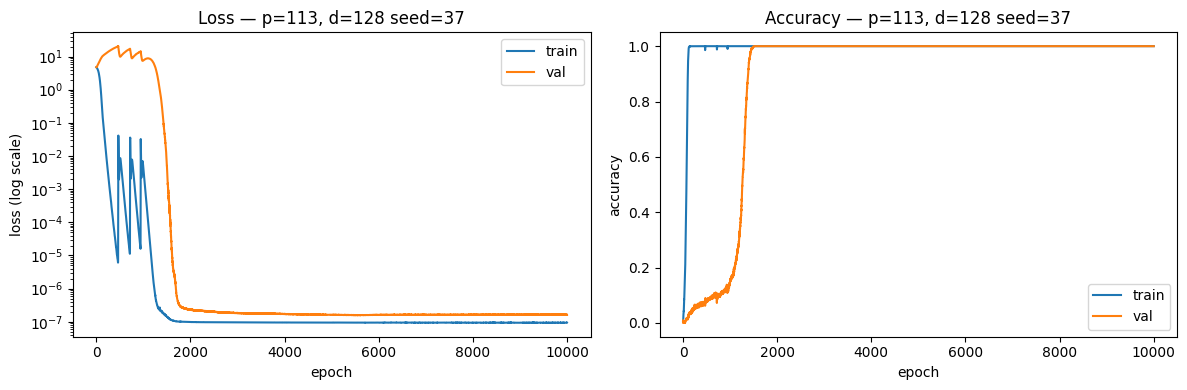

In [16]:
import os
import torch
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple
from mintrans_clean import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

files = os.listdir('./random_seeds')

path_wd = [{ "wd": decay.split('wd')[-1 :][0].split('_')[-1:][0].split('.pth')[0], "path": decay }for decay in files]


cfg = TrainConfig()


for obj in path_wd:
    path = os.path.join("random_seeds", obj['path'])
    random_seed = obj['wd']

    model = MinimalTransformer(
        vocab_size=cfg.vocab_size, d_model=cfg.d_model, n_heads=cfg.n_heads,
        num_layers=cfg.num_layers, max_seq_len=cfg.seq_len,
        hidden_mlp=cfg.hidden_mlp,
    ).to(device)

    skeletons = torch.load(path, map_location=device)

    history = skeletons['history']

    plot_training_curves(history, title=f"p={cfg.p}, d={cfg.d_model} seed={random_seed}")
    # plot_spectral_history(history)